In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/weather_data.csv")

In [3]:
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)
print("\n Sample Output")
df.head()

Shape: (1000000, 6)

Column Names:
Index(['Location', 'Date_Time', 'Temperature_C', 'Humidity_pct',
       'Precipitation_mm', 'Wind_Speed_kmh'],
      dtype='object')

 Sample Output


,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622


In [4]:
print(df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)

Location            0
Date_Time           0
Temperature_C       0
Humidity_pct        0
Precipitation_mm    0
Wind_Speed_kmh      0
dtype: int64


In [5]:
df['Date_Time'] = pd.to_datetime(df['Date_Time'])
df['Month'] = df['Date_Time'].dt.month

def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8]:
        return "Monsoon"
    else:
        return "Autumn"

df['Season'] = df['Month'].apply(get_season)

print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)
print("\n Sample Output")
df.head()

Shape: (1000000, 8)

Column Names:
Index(['Location', 'Date_Time', 'Temperature_C', 'Humidity_pct',
       'Precipitation_mm', 'Wind_Speed_kmh', 'Month', 'Season'],
      dtype='object')

 Sample Output


,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,Month,Season
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540,1,Winter
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161,5,Summer
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951,5,Summer
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303,2,Winter
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622,4,Summer


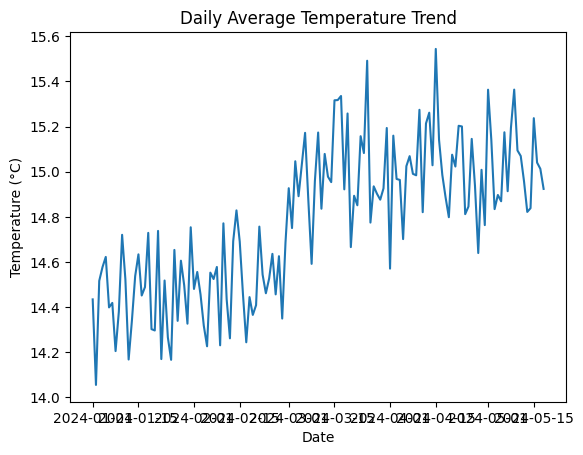

In [11]:
df['Date'] = df['Date_Time'].dt.date
daily_temp = df.groupby('Date')['Temperature_C'].mean()

plt.figure()

plt.plot(daily_temp.index, daily_temp.values)

plt.title("Daily Average Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.show()

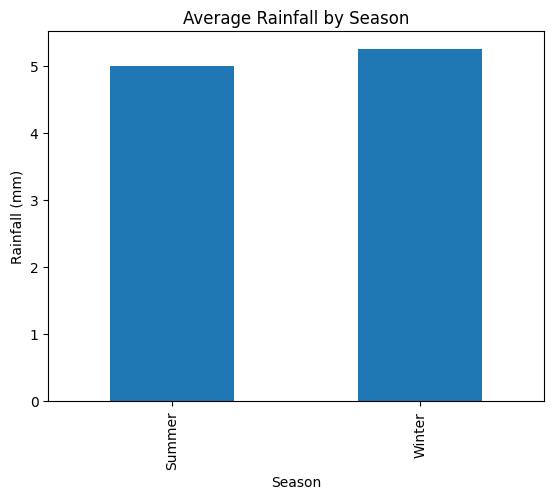

In [7]:
season_rain = df.groupby('Season')['Precipitation_mm'].mean()

season_rain.plot(kind='bar')

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.show()

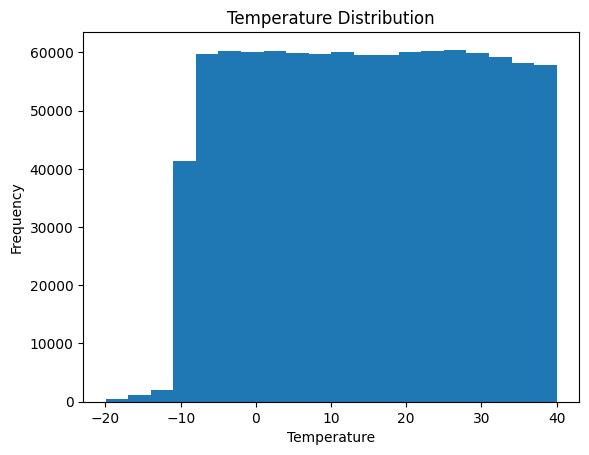

In [8]:
plt.hist(df['Temperature_C'], bins=20)

plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()

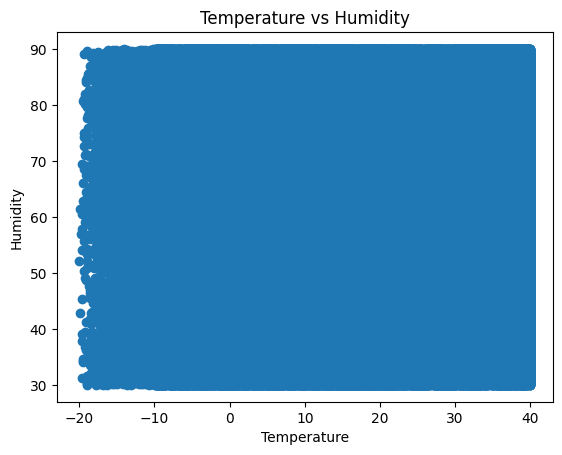

In [9]:
plt.scatter(df['Temperature_C'], df['Humidity_pct'])

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature")
plt.ylabel("Humidity")

plt.show()

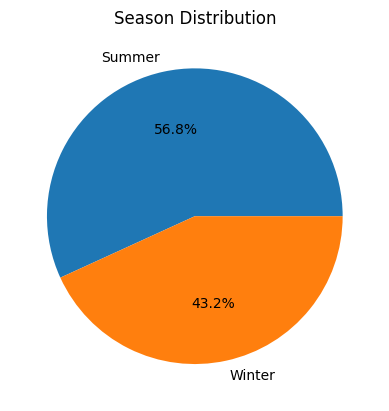

In [10]:
season_counts = df['Season'].value_counts()

plt.pie(season_counts, labels=season_counts.index, autopct='%1.1f%%')

plt.title("Season Distribution")

plt.show()